# Building an Image Classifier with PyTorch — ChatGPT/Codex

**Assignment:** regenerate the image-classification workflow from the previous session, including training-accuracy plots, and submit a newly executed notebook and its HTML rendering.

This notebook was freshly assembled and executed on September 25, 2026, using the seven generated scripts from the earlier session.

**Reference:** Aurélien Géron, *Hands-On Machine Learning with Scikit-Learn and PyTorch* (2025), Chapter 10, “Building an Image Classifier with PyTorch,” cells 111–132 of the supplied `10_neural_nets_with_pytorch.ipynb`. The reference's `train2` helper and 20-epoch setting occur earlier in that notebook. This is a self-contained adaptation generated by OpenAI Codex; it does not claim to be a Claude run.

## Run instructions
Use Python 3.12 with the supplied pinned requirements (the reference requires Python 3.10 or newer). Install `requirements.txt` in your environment, select that environment as the notebook kernel, and run all cells from top to bottom with this folder as your working directory. The first run downloads Fashion-MNIST to `datasets/`; generated metrics, plots and weights are saved in `artifacts/`. Installation is a prerequisite, not a hidden notebook step.

## Method and scope
Fashion-MNIST contains 60,000 training and 10,000 test grayscale images of size 28 × 28. We split the training pool into 55,000 training and 5,000 validation examples with seed 42. The network is Flatten → Linear(784, 300) → ReLU → Linear(300, 100) → ReLU → Linear(100, 10), trained with cross-entropy and SGD, learning rate 0.1, batch size 32, for 20 epochs. These choices follow the supplied reference.

Added features include per-epoch accuracy and loss plots, sample-weighted metrics, validation-based checkpoint selection, held-out test evaluation, saved results, and a save/reload check. Accuracy is computed directly as correct predictions divided by sample count, without an extra TorchMetrics dependency. Training accuracy measures predictions during parameter updates; validation accuracy measures the model after each epoch. They are not measured at exactly the same model state. Test data is not used for checkpoint selection. We use CPU with deterministic operations; results can still vary across software versions and hardware.

## Script-to-cell mapping
Each numbered stage below contains the **exact source** of its matching `scripts/NN_*.py` file. The seven stage files share state and must execute in order; `run_all.py` runs them together outside Jupyter. `build_notebook.py` assembles this notebook and `execute_notebook.py` executes it and exports HTML; these tooling scripts are not classifier cells.


## Stage 1 / code cell 1: Setup and reproducibility

**Generated script:** `scripts/01_setup.py`

Imports, explicit configuration and output directories.

In [1]:
"""Stage 1: imports and reproducible configuration (shared notebook namespace)."""
from pathlib import Path
import copy
import csv
import json
import platform
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision.transforms import v2 as T

SEED = 42
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.1
# CPU is fast for this small MLP and makes this submitted run reproducible.
device = torch.device("cpu")
torch.set_num_threads(2)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True})
print(f"Python {platform.python_version()} | PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"Device: {device}; seed: {SEED}; epochs: {EPOCHS}; batch size: {BATCH_SIZE}")


Python 3.12.14 | PyTorch 2.8.0 | torchvision 0.23.0
Device: cpu; seed: 42; epochs: 20; batch size: 32


## Stage 2 / code cell 2: Dataset and inspection

**Generated script:** `scripts/02_data.py`

Download and scale images to [0, 1], split the training pool, create loaders, and inspect examples.

Training: 55,000; validation: 5,000; test: 10,000
Example: shape=(1, 28, 28), dtype=torch.float32, label=Ankle boot


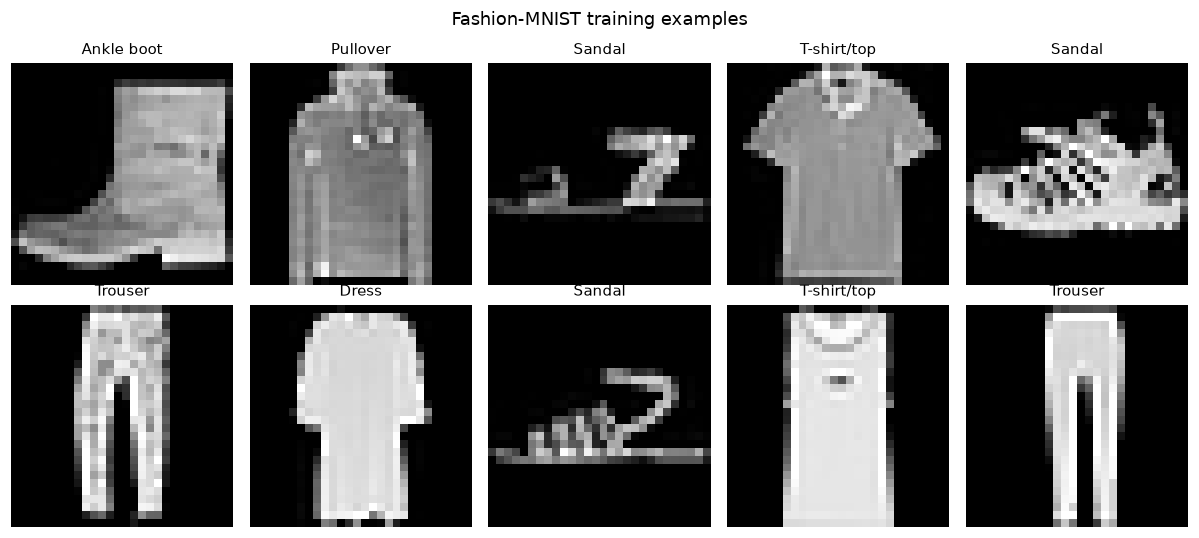

In [2]:
"""Stage 2: download Fashion-MNIST and create disjoint data loaders."""
to_tensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=to_tensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=to_tensor)
train_data, valid_data = random_split(
    train_and_valid_data, [55_000, 5_000],
    generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED), num_workers=0)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, num_workers=0)
class_names = train_and_valid_data.classes
assert set(train_data.indices).isdisjoint(valid_data.indices)
image, label = train_data[0]
assert image.shape == (1, 28, 28) and image.dtype == torch.float32
assert 0 <= image.min() <= image.max() <= 1
print(f"Training: {len(train_data):,}; validation: {len(valid_data):,}; test: {len(test_data):,}")
print(f"Example: shape={tuple(image.shape)}, dtype={image.dtype}, label={class_names[label]}")
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, index in zip(axes.flat, range(10)):
    image, label = train_data[index]
    ax.imshow(image.squeeze().numpy(), cmap="gray")
    ax.set_title(class_names[label], fontsize=10)
    ax.axis("off")
fig.suptitle("Fashion-MNIST training examples")
fig.tight_layout()
fig.savefig(ARTIFACTS / "training_examples.png", bbox_inches="tight")
plt.show()
plt.close(fig)


## Stage 3 / code cell 3: Classifier

**Generated script:** `scripts/03_model.py`

Define the reference MLP and check its output shape and 266,610 trainable parameters. CrossEntropyLoss accepts logits, so no softmax is applied before training loss.

In [3]:
"""Stage 3: define the reference multilayer perceptron."""
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs=784, n_hidden1=300, n_hidden2=100, n_classes=10):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(), nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2), nn.ReLU(),
            nn.Linear(n_hidden2, n_classes))

    def forward(self, inputs):
        return self.mlp(inputs)

torch.manual_seed(SEED)
model = ImageClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
assert model(torch.zeros(2, 1, 28, 28, device=device)).shape == (2, 10)
assert parameter_count == 266_610
print(model)
print(f"Trainable parameters: {parameter_count:,}")


ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Trainable parameters: 266,610


## Stage 4 / code cell 4: Training and validation

**Generated script:** `scripts/04_training.py`

Train for 20 epochs and retain the model with the highest validation accuracy. Loss is weighted by batch size, including the final partial batch.

In [4]:
"""Stage 4: train for 20 epochs, tracking sample-weighted metrics."""
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        loss_sum += criterion(logits, targets).item() * targets.size(0)
        correct += (logits.argmax(dim=1) == targets).sum().item()
        count += targets.size(0)
    return loss_sum / count, correct / count

history = []
best_valid_accuracy = -1.0
best_state = None
start_time = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum, correct, count = 0.0, 0, 0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * targets.size(0)
        correct += (logits.detach().argmax(dim=1) == targets).sum().item()
        count += targets.size(0)
    valid_loss, valid_accuracy = evaluate(model, valid_loader)
    row = dict(epoch=epoch, train_loss=loss_sum/count, train_accuracy=correct/count,
               valid_loss=valid_loss, valid_accuracy=valid_accuracy)
    history.append(row)
    if valid_accuracy > best_valid_accuracy:
        best_valid_accuracy = valid_accuracy
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch:02d}/{EPOCHS}: loss={row['train_loss']:.4f}, "
          f"train accuracy={row['train_accuracy']:.2%}, "
          f"validation accuracy={valid_accuracy:.2%}", flush=True)
training_seconds = time.perf_counter() - start_time
assert len(history) == EPOCHS
assert all(np.isfinite(list(row.values())).all() for row in history)
assert all(0 <= row[key] <= 1 for row in history
           for key in ["train_accuracy", "valid_accuracy"])
with (ARTIFACTS / "history.csv").open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(history[0]))
    writer.writeheader()
    writer.writerows(history)
print(f"Training time: {training_seconds:.1f} seconds; best validation epoch: {best_epoch}")


Epoch 01/20: loss=0.6047, train accuracy=77.85%, validation accuracy=84.08%
Epoch 02/20: loss=0.4078, train accuracy=84.97%, validation accuracy=85.56%
Epoch 03/20: loss=0.3628, train accuracy=86.39%, validation accuracy=85.80%
Epoch 04/20: loss=0.3353, train accuracy=87.50%, validation accuracy=86.50%
Epoch 05/20: loss=0.3156, train accuracy=88.22%, validation accuracy=87.20%
Epoch 06/20: loss=0.2981, train accuracy=88.86%, validation accuracy=87.04%
Epoch 07/20: loss=0.2850, train accuracy=89.17%, validation accuracy=87.20%
Epoch 08/20: loss=0.2717, train accuracy=89.82%, validation accuracy=87.46%
Epoch 09/20: loss=0.2617, train accuracy=90.15%, validation accuracy=87.84%
Epoch 10/20: loss=0.2535, train accuracy=90.50%, validation accuracy=88.22%
Epoch 11/20: loss=0.2436, train accuracy=90.88%, validation accuracy=88.32%
Epoch 12/20: loss=0.2378, train accuracy=91.01%, validation accuracy=87.36%
Epoch 13/20: loss=0.2295, train accuracy=91.34%, validation accuracy=88.02%
Epoch 14/20:

## Stage 5 / code cell 5: Accuracy and loss plots

**Generated script:** `scripts/05_learning_curves.py`

Plot both training and validation accuracy by epoch, alongside cross-entropy loss. This is the requested extension.

Training accuracy is accumulated during updates; validation uses the model at each epoch's end.


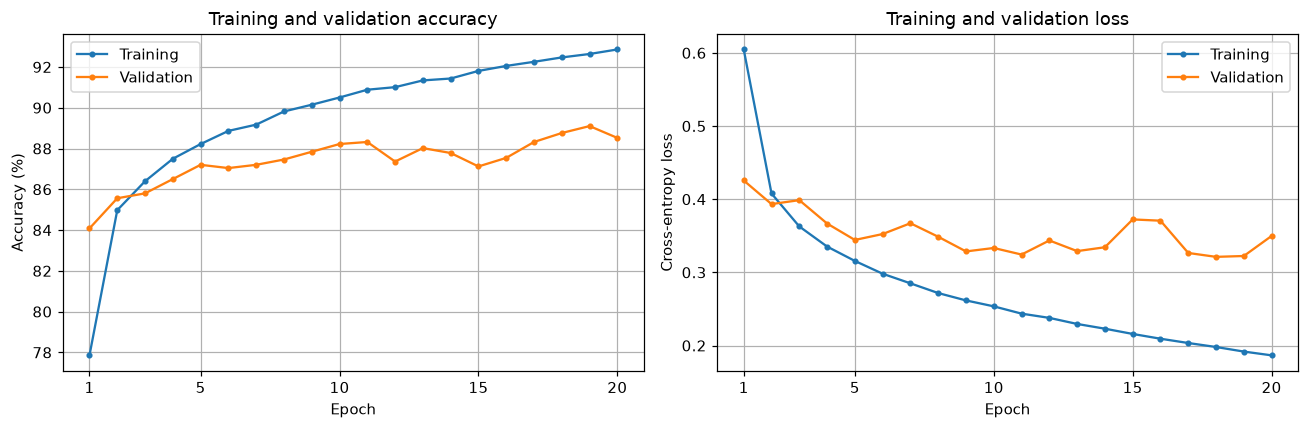

In [5]:
"""Stage 5: plot the requested training accuracy plus validation and loss."""
epochs = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for prefix, label in [("train", "Training"), ("valid", "Validation")]:
    axes[0].plot(epochs, [100*row[f"{prefix}_accuracy"] for row in history],
                 marker="o", markersize=3, label=label)
    axes[1].plot(epochs, [row[f"{prefix}_loss"] for row in history],
                 marker="o", markersize=3, label=label)
axes[0].set(title="Training and validation accuracy", ylabel="Accuracy (%)")
axes[1].set(title="Training and validation loss", ylabel="Cross-entropy loss")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACTS / "learning_curves.png", bbox_inches="tight")
plt.show()
plt.close(fig)
print("Training accuracy is accumulated during updates; validation uses the model at each epoch's end.")


## Stage 6 / code cell 6: Test evaluation and predictions

**Generated script:** `scripts/06_evaluation.py`

Evaluate the selected model once on the test set, inspect predictions, and save metrics. Top-four probabilities are selected from the full ten-class softmax; they are not renormalized.

Selected epoch: 19; test loss: 0.3255; test accuracy: 88.73%
Example 1: true=Ankle boot; predicted=Ankle boot
[('Ankle boot', 0.999), ('Sneaker', 0.001), ('Sandal', 0.0), ('T-shirt/top', 0.0)]
Example 2: true=Pullover; predicted=Pullover
[('Pullover', 0.9968), ('Coat', 0.0031), ('Shirt', 0.0), ('T-shirt/top', 0.0)]
Example 3: true=Trouser; predicted=Trouser
[('Trouser', 1.0), ('Dress', 0.0), ('T-shirt/top', 0.0), ('Coat', 0.0)]
Out[6]: 405


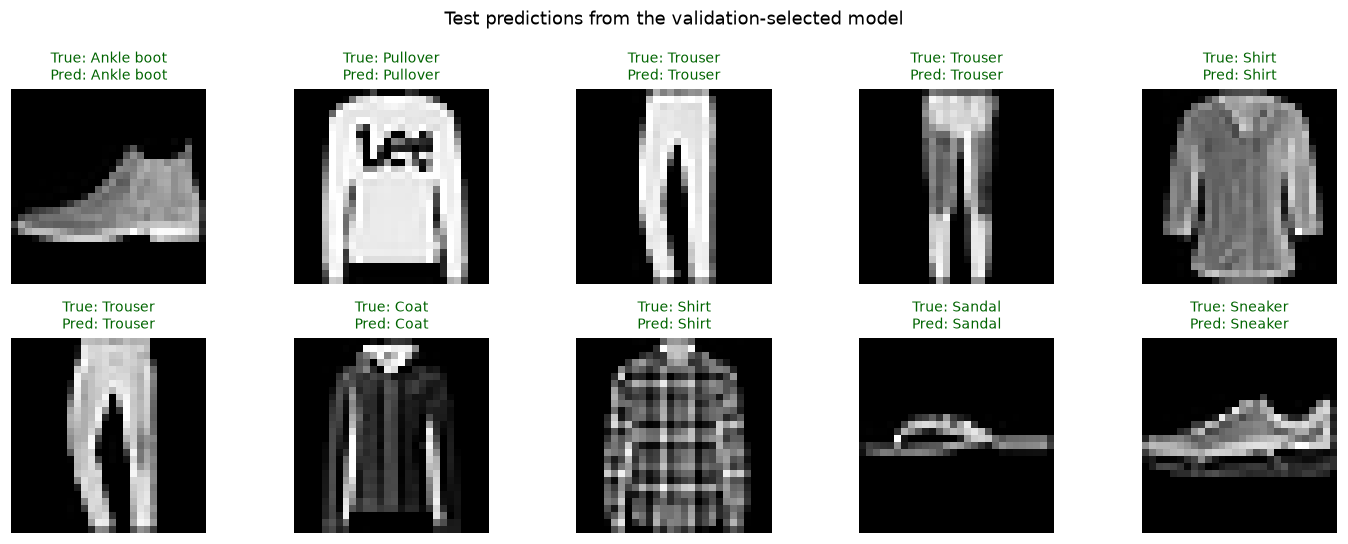

In [6]:
"""Stage 6: evaluate the validation-selected model on the untouched test set."""
model.load_state_dict(best_state)
test_loss, test_accuracy = evaluate(model, test_loader)
print(f"Selected epoch: {best_epoch}; test loss: {test_loss:.4f}; test accuracy: {test_accuracy:.2%}")
images, targets = next(iter(test_loader))
model.eval()
with torch.inference_mode():
    logits = model(images[:10].to(device))
    probabilities = logits.softmax(dim=1).cpu()
    predictions = probabilities.argmax(dim=1)
assert torch.allclose(probabilities.sum(dim=1), torch.ones(10), atol=1e-6)
top4_probabilities, top4_indices = probabilities[:3].topk(4, dim=1)
for index in range(3):
    print(f"Example {index + 1}: true={class_names[targets[index]]}; "
          f"predicted={class_names[predictions[index]]}")
    print([(class_names[c], round(float(p), 4))
           for p, c in zip(top4_probabilities[index], top4_indices[index])])
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for index, ax in enumerate(axes.flat):
    ax.imshow(images[index].squeeze().numpy(), cmap="gray")
    correct = predictions[index] == targets[index]
    ax.set_title(f"True: {class_names[targets[index]]}\nPred: {class_names[predictions[index]]}",
                 fontsize=9, color="darkgreen" if correct else "firebrick")
    ax.axis("off")
fig.suptitle("Test predictions from the validation-selected model")
fig.tight_layout()
fig.savefig(ARTIFACTS / "test_predictions.png", bbox_inches="tight")
plt.show()
plt.close(fig)
results = {"seed": SEED, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
           "learning_rate": LEARNING_RATE, "best_epoch": best_epoch,
           "best_validation_accuracy": best_valid_accuracy,
           "final_training_accuracy": history[-1]["train_accuracy"],
           "test_loss": test_loss, "test_accuracy": test_accuracy,
           "training_seconds": training_seconds, "parameter_count": parameter_count,
           "python": platform.python_version(), "torch": str(torch.__version__),
           "torchvision": str(torchvision.__version__), "device": str(device)}
(ARTIFACTS / "results.json").write_text(json.dumps(results, indent=2) + "\n")


## Stage 7 / code cell 7: Save and reload verification

**Generated script:** `scripts/07_save_reload.py`

Save model weights, instantiate a fresh model, and check that its logits match the original model.

In [7]:
"""Stage 7: save weights and verify that a fresh model reproduces predictions."""
checkpoint_path = ARTIFACTS / "fashion_mnist_mlp.pt"
torch.save(model.state_dict(), checkpoint_path)
reloaded_model = ImageClassifier().to(device)
reloaded_model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
reloaded_model.eval()
with torch.inference_mode():
    reloaded_logits = reloaded_model(images[:10].to(device))
assert torch.allclose(logits, reloaded_logits, atol=1e-6)
print(f"Saved {checkpoint_path}; reload verification passed.")


Saved artifacts/fashion_mnist_mlp.pt; reload verification passed.


## Interpretation and limitations
The printed metrics and embedded figures above are outputs from the executed code. Increasing training accuracy with stagnant or falling validation accuracy suggests overfitting. Validation-based selection mitigates selecting a worse final epoch, but does not establish generalization beyond this dataset. This is one seeded run of a simple fully connected baseline, not an architecture comparison or evidence of a difference between Claude and OpenAI. Results are printed above and saved to `artifacts/results.json` when the notebook runs.
